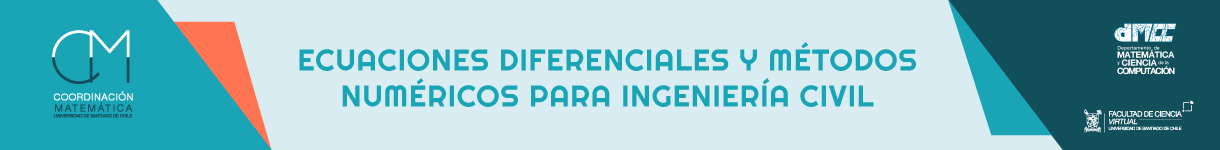

# **Semana 2:**
- Librería SymPy y principales comandos para el cálculo simbólico para funciones, límites, derivadas e integrales.
- Verificar la solución de una Ecuación Diferencial Ordinaria mediante cálculo simbólico en Python.
- Resolución de Ecuaciones Diferenciales Ordinarias mediante cálculo simbólico y comandos específicos en Python.


# Resumen de comandos principales de la clase:
- **Variables y Funciones:** Symbol, symbols, Function. Por ejemplo,
el siguiente código declara a $x$ como una variable independiente e $y$ como dependiente:
```
x = sp.Symbol('x')    #También se puede definir como sp.symbols('x')
y = sp.Function('y')  #También se puede definir como sp.Function('y')(x)
```

- **Derivadas:** Para calcular la derivada de la función $y$ respecto a $x$ usamos `y(x).diff(x)` y para la $n-$ésima derivada usamos `y(x).diff(x,n)` o `Derivative(y(x), x, n)`.

- **Límites:** Para determinar el límite de una función $y(x)$ con $x\rightarrow x_0$, es decir $\lim_{x\rightarrow 0} y(x)$, se escribe ```limit(expresión o variable que depende de x, x, x_0)```.

- **Integración:** Para una integral indefinida usamos ```integrate(exp(x)*sin(x) + exp(x)*cos(x), x)```, y para una integral definida usamos el mismo comando pero agregando el dominio como argumento ```integrate(sin(x**2), (x, -oo, oo))```.

- **Ecuaciones Diferenciales Ordinarias:** Utilizamos el comando `dsolve`.

Además, para visualizar en formato LaTeX, usamos el comando `sp.init_printing(use_latex='mathjax')`.

# **EJEMPLO:**
Consideremos la función $f(x)=x^3-\frac{1}{x^2}$ y determinemos:
- $x(1)$
- $\lim_{x\rightarrow 1}f(x)$
- $\lim_{x\rightarrow \infty}{f(x)}$
- $\frac{df}{dx}$
- $\frac{d^2 f}{dx^2}$
- $\int f(x)dx$
- $\int_{1}^{3} f(x) dx$



In [1]:
import sympy as sp
sp.init_printing(use_latex='mathjax')

# Definimos la variable independiente x
x = sp.symbols('x')

# Definimos la expresión de la función. Aquí asignamos la igualdad y(x) = x**3 - 1/x**2. También, se puede definir con el comando Function como se verá en la siguiente sección.
y = x**3 - 1/x**2

# Evaluamos la expresión en x = 1. El comando .subs() reemplaza x por 1. Si "y" se define con el comando Function, dependiendo de cómo se haga [y=sp.Function('y') y no como y=sp.Fuction('y')(x)], la evaluación se puede hacer como y(1).
resultado1= y.subs(x,1)

# Calculamos el límite con x->1
resultado2=limit_f = sp.limit(y, x, 1)

# Límite de y con x tendiendo a infinito
liminf = sp.limit(y, x, sp.oo)

# Primera derivada: dy/dx
derivada_1 = sp.diff(y, x)

# Segunda derivada: d²y/dx²
derivada_2 = sp.diff(y, x, 2)

# Integral indefinida
integral1=sp.integrate(y,x)

#Integral definida
integral2=sp.integrate(y,(x,1,3))

print(f"La función es: y(x) = {y}")
print(f"El valor es y(1)={resultado1}")
print(f"El valor del límite cuando x->1 es {resultado2}")
print(f"f'(x) = {derivada_1}")
print(f"f''(x) = {derivada_2}")
print(f"lim y con x->infinito es {liminf}")
print(f"El valor de la integral indefinida es {integral1}")
print(f"El valor de la integral definida es {integral2}")

y
resultado1
resultado2
derivada_1
derivada_2
integral1
integral2
liminf                    #Obs: Termina imprimiendo solo el último en formato LaTex


La función es: y(x) = x**3 - 1/x**2
El valor es y(1)=0
El valor del límite cuando x->1 es 0
f'(x) = 3*x**2 + 2/x**3
f''(x) = 6*(x - 1/x**4)
lim y con x->infinito es oo
El valor de la integral indefinida es x**4/4 + 1/x
El valor de la integral definida es 58/3


∞

# Ecuaciones diferenciales con Python
Mientras que algunos problemas de Ecuaciones Diferenciales Ordinarias se pueden resolver con métodos analíticos, como deben haber visto en cátedra, son mucho más comunes los problemas que no se pueden resolver analíticamente. Por lo tanto, en estos casos debemos recurrir a los métodos numéricos. Es aquí, donde el poder de las computadoras y los paquetes científicos de `Python` como `NumPy`, `Matplotlib`, `SymPy` y `SciPy`, se vuelven sumamente útiles. Veamos como podemos utilizar la potencia computacional para resolver Ecuaciones Diferenciales.

## Soluciones analíticas con `Python`
El paquete `SymPy` nos proporciona un solucionador genérico de Ecuaciones Diferenciales Ordinarias, `sympy.dsolve`, el cual es capaz de encontrar soluciones analíticas a muchas EDOs elementales. A pesar de que este comando se puede utilizar para resolver muchas EDOs (simbólicamente), como veremos a continuación, debemos tener en cuenta que la mayoría de las EDOs no se pueden resolver analíticamente.

Consideremos la EDO:

$$\dfrac{dy}{dx}=-3x^2y+6x^2$$

¿Cuál es su solución?

Encontremos una solución todos juntos en pizarra.

Ahora, usaremos la librería `SymPy` para solucionar la siguiente EDO. Para esto, definimos:
* La variable $x$ utilizando el objeto `Symbol` o `symbols`.
* La variable $y$, que al ser una función, obviamente debe definirse como objeto `Function`.

Luego, usamos el comando `sp.Eq()` para respresentar una ecuación.

In [1]:
import matplotlib.pyplot as plt
import sympy as sp
import numpy as np

In [2]:
from scipy import integrate           #Se agrega desde la paquetería SciPy la función "integrate" para integrar funciones de manera simbólica
sp.init_printing(use_latex='mathjax') # Importamos el módulo de LaTeX para imprimir con notación matemática
                                      #Para imprimir en modo LaTex se debe escribir la variable a imprimir solamente, no mediante Print()
# Definimos las variables
x = sp.Symbol('x', real=True )
y = sp.Function('y')

#Expresamos la ecuación en término de las variables definidas anteriormente
f = 6*x**2 - 3*x**2*(y(x))    #Expresión que corresponde a la parte derecha de la ecuación
sp.Eq(y(x).diff(x), f)        #Expresa la ecuación diferencial, donde el comando .Eq(y(x).diff(x)) agrega la derivada de "y" respecto a "x". Para esto "y" tenía que estar definida como una función de "x"
                              #La coma "," separa el miembro izquierdo y derecho de la ecuación diferencial

d               2           2
──(y(x)) = - 3⋅x ⋅y(x) + 6⋅x 
dx                           

Luego, utilizamos el comando `dsolve` para determinar la solución a la ecuación:
$$\frac{dy}{dx}=-3x^2y+6x^2$$

In [3]:
#El comando dsolve entrega la solución de la ecuación diferencial
sp.dsolve(y(x).diff(x)-f)           #Debemos entregar como parámetro la ecuación igualada a cero, por esto se escribe y(x).diff(x)-f


             3    
           -x     
y(x) = C₁⋅ℯ    + 2

**Observación:** Para el futuro, algunos atributos adicionales para las variables son:



```
integer=True
real=True
positive=True
```



#**EJEMPLO:** Resolviendo una EDO de segundo orden


In [4]:
# Definir variables y funciones
t = sp.symbols('t')                 #aquí se usó el comando "symbols" en vez de "Symbol"
y = sp.Function('y')(t)             #A diferencia del ejemplo anterior se definió y como Function('y)(t), entonces después debemos llamar a la función y como "y" y no como "y(t)"

# Definir ecuación: y''(t) - y(t) = exp(t)
edo = sp.Eq(y.diff(t, 2) - y, sp.exp(t))
edo


         2            
        d            t
-y(t) + ───(y(t)) = ℯ 
          2           
        dt            

In [5]:
# Resolver
solucion = sp.dsolve(edo, y)        #Como la variable "edo" tiene asignada la ecuación diferencial, indicamos en sus argumentos la ecuación (edo) y la incógnita (y)
solucion

           -t   ⎛     t⎞  t
y(t) = C₂⋅ℯ   + ⎜C₁ + ─⎟⋅ℯ 
                ⎝     2⎠   

#**EJEMPLO:** Ingreso de las condiciones iniciales en un PVI
Consideremos la ecuación diferencial:
$$y'=y;\quad\quad y(0)=2$$

A diferencia del ejemplo anterior, para agregar una condición inicial, debemos agregar un argumento en la función `dsolve`. En este caso, la condición inicial $y(0)=2$ se ingresa:



```
ics={y.subs(x,0):2}
```

Así, la implementación del código para determinar la solución al PVI es:




In [6]:
x = sp.symbols('x')
y = sp.Function('y')(x)

# Definir la ecuación diferencial: y' = y
edo = sp.Eq(y.diff(x), y)

# Resolver con condición inicial y(0) = 2
solucion = sp.dsolve(edo, y, ics={y.subs(x, 0): 2})           #ics define las condiciones iniciales. El argumento de la función indica que para la variable x=0, la variable dependiente y=2
solucion


          x
y(x) = 2⋅ℯ 

De manera alternativa, podemos tener un código equivalente pero que la definición de $y$ como función de $x$ no sea explícita. Sin embargo, es importante ser consistente con la notación en las líneas siguientes de código.

A continuación, se muestra cómo queda escrito de manera equivalente sin la dependencia explícita:

In [9]:
x=sp.symbols('x')
y=sp.Function('y')

edo=sp.Eq(y(x).diff(x),y(x))              #En este caso, como se define y=sp.Function('y') sin la dependencia explícita de x, debemos escribir y(x) cada vez que deseemos usar "y" como una función de x

solucion=sp.dsolve(edo,y(x),ics={y(0):2})
solucion

solucion.subs(x,0)                 #Esta línea de comando permite evaluar la solución en un punto. En este caso se evalúa la solución y=2 e^x en x=0, que permite corroborar la condición inicial.

y(0) = 2

# **EJEMPLO:** EDO exacta
Determine la solución de la EDO:
$$(3x^2+6xy^2)dx+(6x^2y+4y^3)dy=0$$

Para resolver la EDO usando `Python` realizamos el siguiente procedimiento:

In [31]:
x=sp.symbols('x')
y=sp.Function('y')(x)

g=(3*x**2+6*x*y**2) + (6*x**2*y+4*y**3)*y.diff(x)          #declaramos la función
g                                                           #la imprimimos para revisar que no hemos cometido errores de tipeo

   2        2      ⎛   2           3   ⎞ d       
3⋅x  + 6⋅x⋅y (x) + ⎝6⋅x ⋅y(x) + 4⋅y (x)⎠⋅──(y(x))
                                         dx      

In [ ]:
sp.dsolve(g, y, hint='1st_exact', simplify=False)

 3      2  2       4        
x  + 3⋅x ⋅y (x) + y (x) = C₁

El resultado que hemos obtenido parece difícil de interpretar, pero si revisamos la resolución vista en clases:

$$x^3+3x^2y^2+y^4=C, \quad\quad\quad C\in\mathbb{R}$$

podemos pensar que hay algún error, sin embargo si despejamos $y$ en términos de $x$, en el ejemplo anterior, tendremos 4 soluciones (por estar elevada a 4):

In [37]:
from sympy.abc import C #identificamos a C como una constante simbólica
sp.solve(x**3+3*x**2*y**2+y**4-C,y) #resolvemos la ecuación en términos de y(x)

⎡       _________________________________        _____________________________ ↪
⎢      ╱             ___________________        ╱             ________________ ↪
⎢     ╱       2     ╱          4      3        ╱       2     ╱          4      ↪
⎢    ╱     3⋅x    ╲╱  4⋅C + 9⋅x  - 4⋅x        ╱     3⋅x    ╲╱  4⋅C + 9⋅x  - 4⋅ ↪
⎢-  ╱    - ──── - ────────────────────── ,   ╱    - ──── - ─────────────────── ↪
⎣ ╲╱        2               2              ╲╱        2               2         ↪

↪ ____         _________________________________        ______________________ ↪
↪ ___         ╱             ___________________        ╱             _________ ↪
↪  3         ╱       2     ╱          4      3        ╱       2     ╱          ↪
↪ x         ╱     3⋅x    ╲╱  4⋅C + 9⋅x  - 4⋅x        ╱     3⋅x    ╲╱  4⋅C + 9⋅ ↪
↪ ─── , -  ╱    - ──── + ────────────────────── ,   ╱    - ──── + ──────────── ↪
↪        ╲╱        2               2              ╲╱        2               2  ↪

↪ ___________⎤
↪ _________

¡Notamos que son el mismo resultado!

Por lo tanto, esto nos deja como moraleja que debemos ser capaces de identificar cuándo los resultados son iguales, a pesar de que las expresiones se representen de manera diferente.

#**EJEMPLO:** Resolviendo y comprobando un PVI

Resolver la EDO vista en clases:

$$\dfrac{dy}{dx} =3x^2y \quad\quad\quad\quad y(1)=2$$

Compruebe sus resultados.

**SOLUCIÓN:**

Primero, escribimos la ecuación en Python:

In [38]:
Eq=sp.diff(y,x)-3*x**2*y      #Planteamos la expresión de la EDO
Eq

     2        d       
- 3⋅x ⋅y(x) + ──(y(x))
              dx      

La solución general para esta ecuación es:

In [39]:
sp.dsolve(Eq)       #Resolvemos la EDO (en este caso igualada a cero)

           ⎛ 3⎞
           ⎝x ⎠
y(x) = C₁⋅ℯ    

Y la solución particular sujeta a las condiciones iniciales es:

In [40]:
resultado=sp.dsolve(Eq, ics={y.subs(x,1):2})
resultado

              ⎛ 3⎞
          -1  ⎝x ⎠
y(x) = 2⋅ℯ  ⋅ℯ    

##¿Es la solución correcta?

Haciendo separación de variables:
$$\dfrac{dy}{dx} =3x^2y ⟹ \dfrac{dy}{y}= 3x^2dx$$

Integrando,

$$\quad\quad\quad ln(y)=x^3+C\quad\quad\quad /exp()$$
$$y=Ce^{x^3}$$

Y, verificaremos paso a paso:

In [41]:
f=1/x                 #Usamos la variable "x", porque ya hemos definido "y" como función. Solo necesitamos comprobar nuestra integración.
sp.integrate(f,x)

log(x)

In [42]:
g=3*x**2
sp.integrate(g,x)

 3
x 

Luego, la solución queda:

In [43]:
e=sp.log(y)-x**3-C
res=sp.solve(e,y)                   #Este comando "solve" sirve para despejar una incógnita en una ecuación
res

⎡      3⎤
⎢ C + x ⎥
⎣ℯ      ⎦

Por otro lado, podemos usar el comando `sp.checkodesol` para verificar si la solución es correcta, que recibe como argumento `checkodesol(expresión de la ecuación, propuesta de solución)`.

In [44]:
sp.checkodesol(Eq,resultado)    #En este caso la salida es un par ordenado (True,0) que indica que al sustituir la solución en la EDO se obtiene 0 significando que la solución es correcta

(True, 0)

# **EJERCICIOS:**

Resolver los siguientes ejercicios comenzando por 3, 4, 9, 1 y 2.

# **Ejercicio 1**

En Python podemos declarar $\sqrt[3]{2}$ de diferentes formas:
* `2**(1/3)` mediante potencias.
* `np.cbrt(2)` mediante el uso de la libreria `numpy`.
* `sp.cbrt(2)` mediante el uso de la libreria `sympy`.

Defina $\sqrt[3]{2}$ usando las formas que se presentan y describa porqué son diferentes. Recuerde registrar su desarrollo de la forma más ordenada y coherente posible.  

#### <span style="color:#8fc5ff">Solución</span>

In [47]:
import numpy as np
import sympy as sp

normal_crbt2 = 2**(1/3)    #Calculamos la raíz cúbica de 2 usando la función de potencia normal de Python
numpy_cbrt2 = np.cbrt(2)    #Calculamos la raíz cúbica de 2 usando NumPy
sympy_cbrt2 = sp.cbrt(2)    #Calculamos la raíz cúbica de 2 usando SymPy

print(f"Raíz cúbica de 2 usando potencia normal de Python: {normal_crbt2}")
print(f"Raíz cúbica de 2 usando NumPy: {numpy_cbrt2}")
sympy_cbrt2

Raíz cúbica de 2 usando potencia normal de Python: 1.2599210498948732
Raíz cúbica de 2 usando NumPy: 1.259921049894873


3 ___
╲╱ 2 

Son diferentes en el sentido que la normal tiene menor precision que la obtenida por la libreria numpy.
La de np es solamente numerica, util para verificar resultados y realizar calculos numericos.
La de sp es algebraica, perfecta para simplificar calculos.

# **Ejercicio 2**

Para este ejercicio, debe notar que al definir las variables en Python obtendrá resultados diferentes si la define como `y=sp.Symbol("y", real= True)` o como `y=sp.Symbol("y")`.

Ahora considere la EDO autónoma:

$$(y^5 - 6 y^4 - 5 y^3 - 10 y^2 - 36 y + 56)dx+(y^2+1)dy = 0$$

* a) Encuentre sus puntos estacionarios usando `y=sp.Symbol("y", real= True)`.
* b) Encuentre sus puntos estacionarios usando `y=sp.Symbol("y")`.
* c) Explique porqué se obtienen resultados diferentes.

Recuerde registrar su desarrollo de la forma más ordenada y coherente posible.

#### <span style="color:#8fc5ff">Solución</span>
Los puntos estacionarios de la EDO autonoma:
$$(y^5 - 6 y^4 - 5 y^3 - 10 y^2 - 36 y + 56)dx+(y^2+1)dy = 0$$
Se encuentran recreando $\frac{dy}{dx}$:
$$\frac{dy}{dx} = -\frac{y^5 - 6 y^4 - 5 y^3 - 10 y^2 - 36 y + 56}{y^2+1}$$
Cuando $\frac{dy}{dx}=0$ este sera un punto estacionario, como el denominador nunca sera 0, las soluciones se encontraran en las raices del polinomio....
$$y^5 - 6 y^4 - 5 y^3 - 10 y^2 - 36 y + 56 = 0$$
* a) Los puntos estacionarios cuando $y\in\reals$:

In [48]:
y = sp.Symbol('y', real=True)
eq = y**5 - 6*y**4 - 5*y**3 - 10*y**2 - 36*y + 56

sp.solve(eq, y)

[-2, 1, 7]

* b) Los puntos estacionarios sin esta restriccion:

In [49]:
y = sp.Symbol('y')
eq = y**5 - 6*y**4 - 5*y**3 - 10*y**2 - 36*y + 56
sp.solve(eq, y)

[-2, 1, 7, -2⋅ⅈ, 2⋅ⅈ]

* c) Debido a que el polinomio es de grado 5 este debe tener 5 raices, pero esto no quiere decir que todas estas deban encontrarse dentro de $\reals$ por ende:
* * Tenemos 3 raices dentro de  $\reals$:
$$y=-2, y=1, y=7$$
* * Y 2 raices dentro de $\mathbb{C}$:
$$y=-2i, y=2i$$

# **Ejercicio 3**

Para trabajar este ejercicio debe notar que al buscar soluciones periódicas de ecuaciones diferenciales que involucran funciones trigonométricas la función `sp.solve(#ecuación#,#variable)` entregará un resultado limitado al argumento principal, mientras que la función `sp.solveset(#ecuación#,#variable)` nos entrega un panorama más amplio. Debemos notar sin embargo que `sp.solveset()` no pone atención en las restricciones de la función.

Ahora considere la EDO

$$\sin y \sqrt{y-1} dx - (x^2-1)dy = 0 $$

* a) Encuentre las soluciones estacionarias de la EDO usando `sp.solve()`.
* b) Encuentre las soluciones estacionarias de la EDO usando `sp.solveset()`.
* c) Explique porqué se obtienen resultados diferentes y qué ventajas tiene cada método.

#### <span style = "color:#8fc5ff"> Solución </span>
Las soluciones estacionarias se encontraran cuando $\frac{dy}{dx}=0$, reordenando la EDO tenemos que:
$$ \frac{dy}{dx}=\frac{\sin{y}\sqrt{y-1}}{x^2-1}$$
Esto se invalida cuando $x=1$ pero lo importante es que los puntos estacionarios entonces se encuentran cuando:
$$\sin{y}\sqrt{y-1}=0$$
* a) Resolviendo esta ecuacion usando `sp.solve()`:

In [65]:
y = sp.Symbol('y')

eq = sp.sin(y) * sp.sqrt(y - 1)

sp.solve(eq, y)

[0, 1, π]

* b) Resolviendo usando `sp.solveset()`:

In [66]:
y = sp.Symbol('y')

eq = sp.sin(y) * sp.sqrt(y - 1)

sp.solveset(eq, y)

{1} ∪ {2⋅n⋅π │ n ∊ ℤ} ∪ {2⋅n⋅π + π │ n ∊ ℤ}

* c) La diferencia entre las soluciones se debe a que `solve()` solo nos entrega las raices principales, sobretodo de las funciones periodicas, ya que entrega una lista, que es por definicion, finita. En el caso de `solveset()` este nos entrega el conjunto solución, conjunto que contiene todas las soluciones posibles.

# **Ejercicio 4**

Resolver el PVI
$$\dfrac{dy}{dx} - y = 2e^x y^2 \quad ; \quad y(1)=\pi.$$

Compruebe la solución utilizando comandos apropiados.


#### <span style = "color:#8fc5ff"> Solución </span>

In [70]:
x = sp.Symbol('x')
y = sp.Function('y')(x)

edo = y.diff(x) - y - 2*sp.exp(x)*y**2
res = sp.dsolve(edo, y, ics={y.subs(x, 1):sp.pi})

sp.checkodesol(edo, res)

(True, 0)

# **Ejercicio 5**

Considere la siguiente EDO:

$$\left[ \dfrac{\ln(\ln(y))}{x}+\dfrac{2}{3}xy^3+6x \right] dx+ \left[\dfrac{\ln(x)}{y\ln(y)}+x^2y^2+4e^{-2y} \right]dy=0.$$

* a) Verifique si es exacta.
* b) Resuelva la ecuación.

#### <span style = "color:#8fc5ff"> Solución </span>
* a) Primero que nada es verificar que:
$$ \frac{\partial M}{\partial y}=\frac{\partial N}{\partial x}\rightarrow M(x,y)=\dfrac{\ln(\ln(y))}{x}+\dfrac{2}{3}xy^3+6x, N(x,y)=\dfrac{\ln(x)}{y\ln(y)}+x^2y^2+4e^{-2y}

In [79]:
# Encontrar las derivadas para comprobar que la EDO es exacta
x = sp.Symbol('x')
y = sp.Symbol('y')

M = sp.log(sp.log(y)) / x + 2*x*y**3 / 3 + 6*x
N = sp.log(x) / (y*sp.log(y)) + x**2*y**2 + 4*sp.exp(-2*y)

if M.diff(y) - N.diff(x) == 0:
    print("La ecuación es exacta.")
else:
    print("La ecuación no es exacta.")

La ecuación es exacta.


&emsp;&emsp;&emsp;&emsp; La EDO es exacta por lo tanto la resolvemos con `sp.dsolve()` y `hint="1st_exact"`
* b) Ahora resolvemos la EDO:

In [90]:
x = sp.Symbol('x')
y = sp.Function('y')(x)

M = sp.log(sp.log(y)) / x + 2*x*y**3 / 3 + 6*x
N = sp.log(x) / (y*sp.log(y)) + x**2*y**2 + 4*sp.exp(-2*y)

EDO = M + N*y.diff(x)  # Planteamos la EDO en términos de M y N
sp.dsolve(EDO, y, hint='1st_exact')

 2 ⎛ 3       ⎞                                          
x ⋅⎝y (x) + 9⎠                              -2⋅y(x)     
────────────── + log(x)⋅log(log(y(x))) - 2⋅ℯ        = C₁
      3                                                 

# **Ejercicio 6**

Usando comando `dsolve` resuelva las siguientes EDOs:

* a) $y' =  \left( \dfrac{y}{x} \right)  + \ln \left( \dfrac{y}{x} \right)$
* b) $(y-\tan y \cos^2 x)dx + \left( \sin x \cos x - x \dfrac{\cos^2 x}{\cos^2 y} \right) dy = 0$
* c) $\sin x - x \cos x - 3x^2 (y-x)^2+3x^2(y-x)^2 y' = 0 \quad ; \quad y(1)=\sqrt{3}$

#### <span style= "color:#8fc5ff"> Solución </span>

In [217]:
x = sp.Symbol('x')
y = sp.Function('y')(x)

In [92]:
a = y / x + sp.log(y / x) - y.diff(x)

sp.dsolve(a, y)

                ⎛y(x)⎞
log(x) = C₁ + li⎜────⎟
                ⎝ x  ⎠

In [ ]:
# Para esta EDO, para que ejecute el comando dsolve, hay que encontrar el factor integrante, que en este caso es 1/cos(x)**2
# Al ser funciones trigonometricas, a dsolve se le dificulta encontrar el factor integrante, por lo que se debe facilitar la simplificación de la ecuación.
# Entonces necesario escribir la ecuación de la siguiente forma:
# Facilitando las simplificaciones trigonometricas para que el comando dsolve pueda resolver la EDO exacta ya que en caso contrario no identificara la EDO como exacta.
b = (y * (1 + sp.tan(x)**2) - sp.tan(y)) + (sp.tan(x) - x * (1 + sp.tan(y)**2))*y.diff(x)


#dsolve() solo por lo general no resuelve EDO's con un minimo de dificultad, asi que hay que basicamente resolverlo por cuenta propia sin la molestia de integrar.
sp.dsolve(b, y, hint='1st_exact')


               ⎛  sin(x)         ⎞                        
-x⋅tan(y(x)) + ⎜- ────── + tan(x)⎟⋅y(x) + y(x)⋅tan(x) = C₁
               ⎝  cos(x)         ⎠                        

In [219]:
c = sp.sin(x) - x*sp.cos(x) - 3*x**2*(y - x)**2 + 3*x**2*(y - x)**2*y.diff(x)

sp.dsolve(c, y, hint='1st_exact', simplify=False, ics={y.subs(x, sp.sqrt(3)): 1})

   3      2             2       3      sin(x)           √3⋅sin(√3)     
- x  + 3⋅x ⋅y(x) - 3⋅x⋅y (x) + y (x) - ────── = -6⋅√3 - ────────── + 10
                                         x                  3          

# **Ejercicio 7**

Con ayuda de `sympy` pero sin usar `dsolve` resuelva  nuevamente los ejercicios del problema anterior.

#### <span style= "color:#8fc5ff"> Solución </span>

In [248]:
### Ejercicio 6. a
x = sp.Symbol('x')
y = sp.Function('y')(x)

a = y / x + sp.log(y / x)

u = sp.Symbol('u')
#du = (y / x).diff(x)
#dy_dx = u.diff(x) * x + u

sol = u* x + u - (u + sp.log(u))

left_side = 1 / sp.log(u)
right_side = 1 / x

integral1 = sp.integrate(left_side, u)
integral2 = sp.integrate(right_side, x)


sol = sp.Eq(integral1, integral2 + sp.symbols('C'))
sol

li(u) = C + log(x)

In [246]:
#### Ejercicio 6. b

x = sp.Symbol('x')
y = sp.Symbol('y')

M = y - sp.cos(x)**2*sp.tan(y)
N = sp.sin(x)*sp.cos(x) - x * sp.cos(x)**2 / sp.cos(y)**2

if sp.simplify(M.diff(y) - N.diff(x)) == 0:
    print("La ecuación es exacta.")
else:
    print("La ecuación no es exacta.")
    
factor_integrante = (M.diff(y) - N.diff(x)) / N
factor_integrante_simplificado = sp.simplify(factor_integrante)

factor_integrante = sp.exp(sp.integrate(factor_integrante_simplificado, x))
factor_integrante

M = sp.simplify(M*factor_integrante)
N = sp.simplify(N*factor_integrante)

if sp.simplify(M.diff(y) - N.diff(x)) == 0:
    print(f"La ecuación es exacta usando el factor de integración: {factor_integrante}")
else:
    print("La ecuación no es exacta.")

f = sp.integrate(M, x)
g = sp.Function('g')(y)

f = f + g

g_diff = sp.simplify(f.diff(y) - N)

# g(y) = 0

f = sp.simplify(f - g)
C = sp.symbols('C')
f = sp.Eq(f, C)
f

La ecuación no es exacta.
La ecuación es exacta usando el factor de integración: cos(x)**(-2)


-x⋅tan(y) + y⋅tan(x) = C

In [249]:
#### Ejercicio 6. c

x = sp.Symbol('x')
y = sp.Symbol('y')

M = sp.sin(x) - x*sp.cos(x) - 3*x**2*(y - x)**2
N = 3*x**2*(y - x)**2

if sp.simplify(M.diff(y) - N.diff(x)) == 0:
    print("La ecuación es exacta.")
else:
    print("La ecuación no es exacta.")
    
x_term = sp.simplify(sp.simplify(M.diff(y) - N.diff(x)) / N)
factor_integrante = sp.exp(sp.integrate(x_term, x))

M = sp.simplify(M*factor_integrante)
N = sp.simplify(N*factor_integrante)

if sp.simplify(M.diff(y) - N.diff(x)) == 0:
    print(f"La ecuación es exacta usando el factor de integración: {factor_integrante}")
else:
    print("La ecuación no es exacta.")

f = sp.integrate(M, x)
g = sp.Function('g')(y)
f = f + g
g_diff = sp.simplify(f.diff(y) - N)

# g(y) = 0

f = sp.simplify(f - g)

C = f.subs(x, sp.sqrt(3)).subs(y, 1)
f = sp.Eq(f, C)
f




La ecuación no es exacta.
La ecuación es exacta usando el factor de integración: x**(-2)


         3   sin(x)     √3⋅sin(√3)            3
- (x - y)  - ────── = - ────────── - (-1 + √3) 
               x            3                  

# **Ejercicio 8**

Dada la EDO
$$\frac{dy}{dx} = \frac{(y^2-1)\sqrt{x}}{2y \ln(y^2-1)}$$
Determine una región $D\subset \mathbb{R}^2$ donde se pueda asegurar la existencia y unicidad de la solución. Encuentre todas las soluciones que satisfacen $y(0)=1$.

#### <span style= "color:#8fc5ff"> Solución </span>
La region $D$ esta limitada por donde $\frac{dy}{dx}$ exista. Por un lado no se ve limitada por $x$, ya que $x\in[-\infty,\infty]$.
Por el otro lado, $y$ al encontrarse en el denominador, tenemos que:
$$ 2y \ln(y^2-1)  \neq 0$$
Para que $\frac{dy}{dx}$ exista en esa region, por un lado sabemos que $2y \neq 0$.
Por el otro:

In [ ]:
x = sp.Symbol('x', real=True)
y = sp.Symbol('y', real=True)

sp.solveset(y**2 - 1 > 0, y, sp.S.Reals)

(-∞, -1) ∪ (1, ∞)

Entonces tenemos que la region es:
$$ D \subset \reals\times((-\infty, -1)\cup(1, \infty)) $$
Y el punto a evaluar $(0, 1) \not \in D$ por lo tanto no vale la pena verificar si su solucion es unica ya que no existe solucion.

# **Ejercicio 9**

Muestre que
$$\mu(x,y) = \frac{1}{\sqrt{x^2+y^2}}$$
es un factor integrante de la EDO
$$dx + \dfrac{1}{y}\left( \sqrt{x^2+y^2}-x\right) dy =0$$
Luego resuelva la EDO sin usar `dsolve`.

**Importante:**
- Primero defina la variable `x` como real e `y` como real y positiva para evitar problemas del tratamiento interno de Python con algunas expresiones.

- Para comprobar que $\mu$ es un factor integrante, defina $x$ e $y$ como variables independientes. En caso contrario, Python usará derivación implícita.

#### <span style= "color:#8fc5ff"> Solución </span>
Demostracion que $u(x,y) = \frac{1}{\sqrt{x^2+y^2}}$ es un factor de integracion de la EDO:

In [323]:
x = sp.Symbol('x', real=True, positive=True)
y = sp.Symbol('y', real=True, positive=True)

u = 1 / sp.sqrt(x**2 + y**2)

M = 1
N = (sp.sqrt(x**2 + y**2) - x) / y

M = sp.simplify(M*u)
N = sp.simplify(N*u)

if sp.simplify(M.diff(y) - N.diff(x)) == 0:
    print(f"La ecuación es exacta usando el factor de integración: {u}")
    
else:
    print("La ecuación no es exacta.")

La ecuación es exacta usando el factor de integración: 1/sqrt(x**2 + y**2)


Resolviendo la EDO ahora que es exacta:

In [324]:
f = sp.simplify(sp.integrate(M, x))
f
g = sp.Function('g')(y)
f = sp.simplify(f + g)
g_diff = sp.simplify(f.diff(y) - N)
g_diff = sp.simplify(g.diff(y) - g_diff)

g = sp.simplify(sp.integrate(g_diff, y)) 
f = sp.Eq(f.subs(sp.Function('g')(y), g), sp.symbols('C'))
f

              ⎛x⎞    
log(y) + asinh⎜─⎟ = C
              ⎝y⎠    

# **Ejercicio 10**

Considere la EDO

$$y'=\tan^2(y)-\csc^2(y)-3$$

* Encuentre todas las soluciones estacionarias de la EDO autónoma
* Construya un campo de direcciones para la EDO en la región
$$D=[-2\pi , 2\pi]\times[-2\pi , 2\pi]$$
grafique las soluciones estacionarias sobre el campo y clasifique los puntos en atractor, repulsor o nodo.
* Sin resolver la EDO, justifique el valor de $\displaystyle\lim_{x \to \infty} y(x)$ para una solución que pase por $y(\pi)=\pi$.

#### <span style= "color:#8fc5ff"> Solución </span>
* Buscando las soluciones que se encuentran cuando:
$$\frac{dy}{dx}=\tan{y}^2-\csc{y}^2-3$$

In [ ]:
import sympy as sp

x = sp.Symbol('x')
y = sp.Symbol('y', real=True)
y_diff = sp.tan(y)**2 - sp.csc(y)**2 - 3

dy = sp.trigsimp(y_diff)

soluciones = sp.solveset(dy, y, domain=sp.S.Reals)
soluciones = sp.simplify(soluciones)
soluciones

Union(ImageSet(Lambda(_n, 2*_n*pi + atan(sqrt(2)/sqrt(-1 + sqrt(5)))/2 + pi/2), Integers), ImageSet(Lambda(_n, 2*_n*pi - atan(sqrt(2)/sqrt(-1 + sqrt(5)))/2 + 3*pi/2), Integers), ImageSet(Lambda(_n, 2*_n*pi - atan(sqrt(2)/sqrt(-1 + sqrt(5)))/2 + pi/2), Integers), ImageSet(Lambda(_n, 2*_n*pi + atan(sqrt(2)/sqrt(-1 + sqrt(5)))/2 + 3*pi/2), Integers))

* Graficando el campo $D=[-2\pi,2\pi]\times[-2\pi,2\pi]$

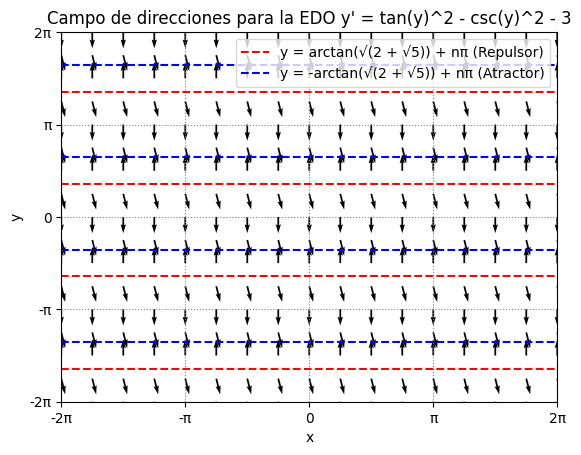

In [1]:
import matplotlib.pyplot as plt
import numpy as np

X, Y = np.meshgrid(np.arange(-2*np.pi, 2*np.pi + 0.01, np.pi / 4), np.arange(-2*np.pi, 2*np.pi + 0.01, np.pi / 4))

U = 1.0
V = np.tan(Y)**2 - (np.sin(Y) + 1e-12)**-2 - 3

N = np.sqrt(U**2 + V**2)
U = U / N
V = V / N

plt.quiver(X, Y, U, V)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Campo de direcciones para la EDO y\' = tan(y)^2 - csc(y)^2 - 3')
plt.xlim(-2*np.pi, 2*np.pi)
plt.ylim(-2*np.pi, 2*np.pi)
plt.yticks(np.arange(-2*np.pi, 2*np.pi + 1, np.pi), labels=['-2π', '-π', '0', 'π', '2π'])
plt.xticks(np.arange(-2*np.pi, 2*np.pi + 1, np.pi), labels=['-2π', '-π', '0', 'π', '2π'])

y_eq_base = np.arctan(np.sqrt(2 + np.sqrt(5)))

for n in range(-3, 4):
    y1 = y_eq_base + n * np.pi
    y2 = -y_eq_base + n * np.pi
    
    if -2*np.pi <= y1 <= 2*np.pi:
        plt.axhline(y1, color='red', linestyle='--', linewidth=1.5, label='y = arctan(√(2 + √5)) + nπ (Repulsor)' if n == 0 else "")
    if -2*np.pi <= y2 <= 2*np.pi:
        plt.axhline(y2, color='blue', linestyle='--', linewidth=1.5, label='y = -arctan(√(2 + √5)) + nπ (Atractor)' if n == 0 else "")

plt.grid(True, linestyle=':', color='gray')
plt.legend(loc='upper right')
plt.show()

* El limite $\lim_{x \to \infty}y(\pi)=\pi$ caera directamente a $\pi n - \arctan{\sqrt{2+\sqrt{5}}}, n\in\mathbb{Z}$ debido a que el valor de:
$$\lim_{x \to \infty}\frac{dy}{dx}(\pi)=-\infty$$
Mostrandonos que $y(\pi)$ caera en picado hacia el atractor que se encuentra en $\pi n - \arctan{\sqrt{2+\sqrt{5}}}, n\in\mathbb{Z}$.